In [1]:
# ============================================================================
# Akita Model Evaluation
# ============================================================================
# This notebook evaluates a trained Akita model on the test set by:
# 1. Loading a trained model checkpoint
# 2. Running inference on test data
# 3. Computing evaluation metrics (Pearson, Spearman, MSE)
# 4. Visualizing predictions vs ground truth
# ============================================================================

In [2]:
# %% Imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error

# Add parent directory (pytorch_akita) to path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from akita_model.model import SeqNN
from data_preprocessing.dataset import HiCDataset

### Configuration

In [3]:
# Model selection
MODEL_IDX = 7  # Which fold/model to evaluate

# Paths
MODEL_PATH = (
    f"/home1/smaruj/pytorch_akita/models/trained_from_scratch/Vian2018_Bcells/checkpoints/"
    f"Akita_v2_mouse_Vian2018_Bcells_model{MODEL_IDX}_from_scratch.pth"
)
DATA_DIR = "/scratch1/smaruj/Akita_pytorch_training_data/mouse_data/Vian2018_Bcells"

# Evaluation parameters
BATCH_SIZE = 2
NUM_WORKERS = 4
NUM_EXAMPLES_TO_PLOT = 3   # Number of examples to visualize
MATRIX_SIZE = 512          # Size of Hi-C contact matrix
DIAGONAL_OFFSET = 2        # Number of diagonals to skip

In [4]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# %% Load Model
print("=" * 70)
print("Loading model...")
print("=" * 70)
print(f"Model path: {MODEL_PATH}")

# Load model
model = SeqNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

print("✓ Model loaded successfully")
print(f"✓ Model set to evaluation mode")
print()

Using device: cuda
Loading model...
Model path: /home1/smaruj/pytorch_akita/models/trained_from_scratch/Vian2018_Bcells/checkpoints/Akita_v2_mouse_Vian2018_Bcells_model7_from_scratch.pth
✓ Model loaded successfully
✓ Model set to evaluation mode



### Load Test Data

In [5]:
# Get test fold files
test_fold = f"fold{MODEL_IDX}"
all_files = [
    os.path.join(DATA_DIR, f) 
    for f in os.listdir(DATA_DIR) 
    if f.endswith(".pt")
]
test_files = [f for f in all_files if test_fold in f]

print(f"Test fold: {test_fold}")
print(f"Found {len(test_files)} test files")

Test fold: fold7
Found 8 test files


In [6]:
# Create test dataset and dataloader
test_dataset = HiCDataset(test_files)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✓ Test dataset created: {len(test_dataset)} samples")
print(f"✓ Dataloader created: {len(test_loader)} batches")
print()

Loading file: /scratch1/smaruj/Akita_pytorch_training_data/mouse_data/Vian2018_Bcells/fold7_5.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/mouse_data/Vian2018_Bcells/fold7_4.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/mouse_data/Vian2018_Bcells/fold7_6.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/mouse_data/Vian2018_Bcells/fold7_7.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/mouse_data/Vian2018_Bcells/fold7_3.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/mouse_data/Vian2018_Bcells/fold7_2.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/mouse_data/Vian2018_Bcells/fold7_0.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/mouse_data/Vian2018_Bcells/fold7_1.pt
Total sequences loaded: 714
✓ Test dataset created: 714 samples
✓ Dataloader created: 357 batches



In [7]:
# Helper Functions

def plot_contact_map(matrix, vmin=-0.6, vmax=0.6, palette="RdBu_r", 
                     width=5, height=5, title=None):
    """
    Plot a Hi-C contact matrix as a heatmap.
    
    Args:
        matrix (np.ndarray): Contact matrix to plot
        vmin (float): Minimum value for color scale
        vmax (float): Maximum value for color scale
        palette (str): Seaborn color palette name
        width (float): Figure width in inches
        height (float): Figure height in inches
        title (str): Optional title for the plot
    """
    fig, ax = plt.subplots(1, 1, figsize=(width, height))
    
    sns.heatmap(
        matrix,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cmap=palette,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=ax
    )
    
    if title:
        ax.set_title(title, fontsize=12, pad=10)
    
    plt.tight_layout()
    plt.show()


def set_diag(matrix, value, k):
    """
    Set a diagonal of a matrix to a specific value.
    
    Args:
        matrix (np.ndarray): Input matrix (modified in-place)
        value: Value to set diagonal elements to
        k (int): Diagonal offset (0=main diagonal, positive=above, negative=below)
    """
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value


def upper_triu_to_matrix(vector_repr, matrix_len=512, num_diags=2):
    """
    Convert upper triangular vector representation back to full symmetric matrix.
    
    Args:
        vector_repr (torch.Tensor or np.ndarray): Upper triangular vector
        matrix_len (int): Size of output square matrix
        num_diags (int): Number of diagonals that were skipped
    
    Returns:
        np.ndarray: Symmetric contact matrix with near-diagonal set to NaN
    """
    # Convert to numpy if needed
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()
    
    # Initialize zero matrix
    matrix = np.zeros((matrix_len, matrix_len))
    
    # Get upper triangular indices (skipping diagonals)
    triu_indices = np.triu_indices(matrix_len, num_diags)
    
    # Fill upper triangle
    matrix[triu_indices] = vector_repr
    
    # Set skipped diagonals to NaN
    for i in range(-num_diags + 1, num_diags):
        set_diag(matrix, np.nan, i)
    
    # Make symmetric
    symmetric_matrix = matrix + matrix.T
    
    return symmetric_matrix

### Run Inference

In [11]:
scd_values = []
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_idx, (ohe_sequence, hic_vector) in enumerate(test_loader):
        # Move to device
        ohe_sequence = ohe_sequence.to(device)
        hic_vector = hic_vector.to(device)
        
        # Forward pass
        outputs = model(ohe_sequence)
        
        # Store predictions and targets
        all_preds.append(outputs.cpu())
        all_targets.append(hic_vector.cpu())
        
        # Compute SCD (Structural Consistency Distance)
        # SCD = sqrt(sum of squared predicted contacts)
        scd_batch = torch.sqrt((outputs ** 2).sum(dim=(1, 2)))
        scd_values.extend(scd_batch.cpu().numpy())
        
        # Progress update
        if (batch_idx + 1) % 10 == 0:
            print(f"Processed {batch_idx + 1}/{len(test_loader)} batches")
            
# Concatenate all batches
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

print(f"✓ Inference complete")
print(f"  Total samples: {len(all_preds)}")
print(f"  Predictions shape: {all_preds.shape}")
print(f"  Targets shape: {all_targets.shape}")
print()

Processed 10/357 batches
Processed 20/357 batches
Processed 30/357 batches
Processed 40/357 batches
Processed 50/357 batches
Processed 60/357 batches
Processed 70/357 batches
Processed 80/357 batches
Processed 90/357 batches
Processed 100/357 batches
Processed 110/357 batches
Processed 120/357 batches
Processed 130/357 batches
Processed 140/357 batches
Processed 150/357 batches
Processed 160/357 batches
Processed 170/357 batches
Processed 180/357 batches
Processed 190/357 batches
Processed 200/357 batches
Processed 210/357 batches
Processed 220/357 batches
Processed 230/357 batches
Processed 240/357 batches
Processed 250/357 batches
Processed 260/357 batches
Processed 270/357 batches
Processed 280/357 batches
Processed 290/357 batches
Processed 300/357 batches
Processed 310/357 batches
Processed 320/357 batches
Processed 330/357 batches
Processed 340/357 batches
Processed 350/357 batches
✓ Inference complete
  Total samples: 714
  Predictions shape: torch.Size([714, 1, 130305])
  Targe

### Compute Metrics

In [9]:
# Flatten predictions and targets for metrics
preds_flat = all_preds.flatten().numpy()
targets_flat = all_targets.flatten().numpy()

# Pearson correlation
pearson_corr, pearson_pval = pearsonr(targets_flat, preds_flat)
print(f"Pearson correlation:  {pearson_corr:.4f} (p-value: {pearson_pval:.2e})")

# Spearman correlation
spearman_corr, spearman_pval = spearmanr(targets_flat, preds_flat)
print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.2e})")

# Mean Squared Error
mse = mean_squared_error(targets_flat, preds_flat)
print(f"MSE:                  {mse:.5f}")

# Mean Absolute Error
mae = np.mean(np.abs(targets_flat - preds_flat))
print(f"MAE:                  {mae:.5f}")

# SCD statistics
scd_mean = np.mean(scd_values)
scd_std = np.std(scd_values)
print(f"\nSCD statistics:")
print(f"  Mean: {scd_mean:.4f}")
print(f"  Std:  {scd_std:.4f}")
print()

Pearson correlation:  0.6192 (p-value: 0.00e+00)
Spearman correlation: 0.5256 (p-value: 0.00e+00)
MSE:                  0.11122
MAE:                  0.24578

SCD statistics:
  Mean: 95.9659
  Std:  51.3211



### Visualize Predictions


Example 1/3
----------------------------------------
Ground Truth:


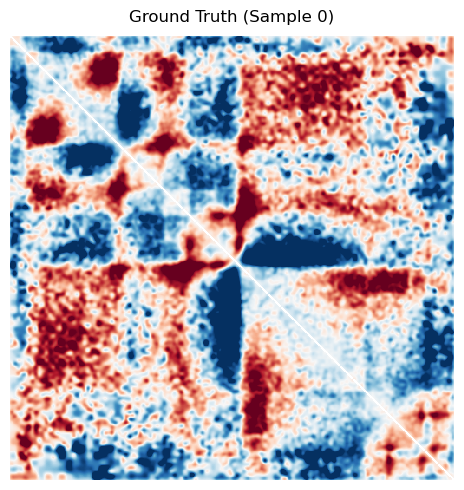

Prediction (Pearson: 0.3136):


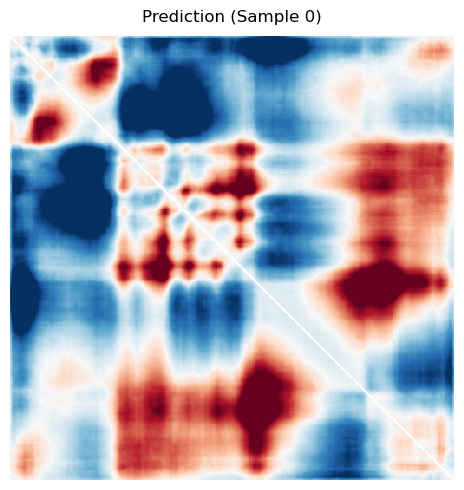


Example 2/3
----------------------------------------
Ground Truth:


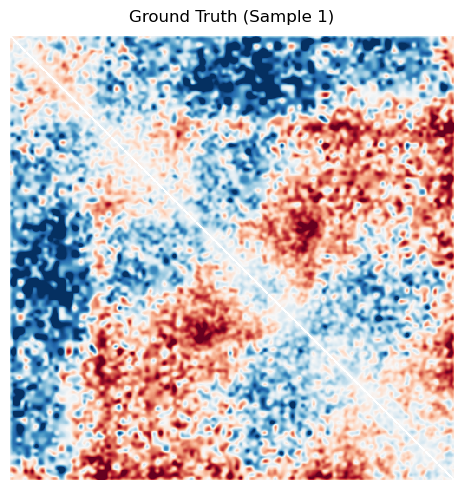

Prediction (Pearson: -0.0733):


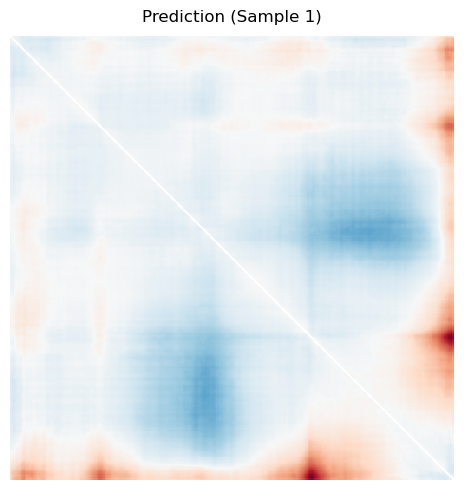


Example 3/3
----------------------------------------
Ground Truth:


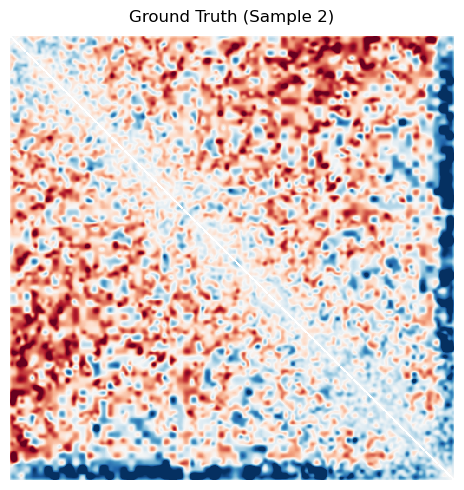

Prediction (Pearson: 0.5505):


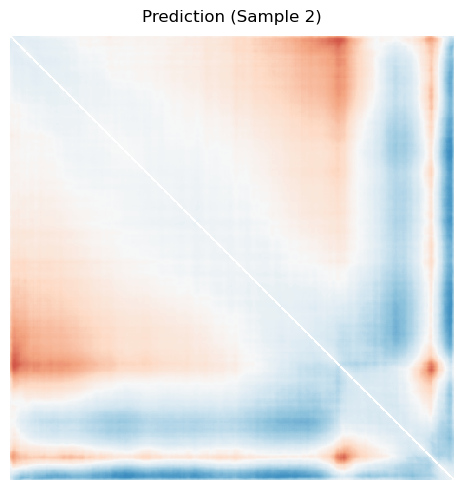

In [12]:
for i in range(min(NUM_EXAMPLES_TO_PLOT, len(all_preds))):
    print(f"\nExample {i + 1}/{NUM_EXAMPLES_TO_PLOT}")
    print("-" * 40)
    
    # Convert to matrices
    target_matrix = upper_triu_to_matrix(
        all_targets[i],
        matrix_len=MATRIX_SIZE,
        num_diags=DIAGONAL_OFFSET
    )
    pred_matrix = upper_triu_to_matrix(
        all_preds[i],
        matrix_len=MATRIX_SIZE,
        num_diags=DIAGONAL_OFFSET
    )
    
    # Compute per-sample correlation
    sample_corr = pearsonr(
        all_targets[i].flatten().numpy(),
        all_preds[i].flatten().numpy()
    )[0]
    
    # Plot target
    print("Ground Truth:")
    plot_contact_map(target_matrix, title=f"Ground Truth (Sample {i})")
    
    # Plot prediction
    print(f"Prediction (Pearson: {sample_corr:.4f}):")
    plot_contact_map(pred_matrix, title=f"Prediction (Sample {i})")